# Fase 2: Análisis estadístico

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df_final = pd.read_csv("./files/df_final.csv")
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   403760 non-null  int64  
 1   Loyalty Number               403760 non-null  int64  
 2   Year                         403760 non-null  int64  
 3   Month                        403760 non-null  int64  
 4   Flights Booked               403760 non-null  int64  
 5   Flights with Companions      403760 non-null  int64  
 6   Total Flights                403760 non-null  int64  
 7   Distance                     403760 non-null  int64  
 8   Points Accumulated           403760 non-null  float64
 9   Points Redeemed              403760 non-null  int64  
 10  Dollar Cost Points Redeemed  403760 non-null  int64  
 11  Country                      403760 non-null  str    
 12  Province                     403760 non-null  str    
 13  City      

### Variables numericas

In [11]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,403760.0,201879.500000,116555.616681,0.00,100939.75,201879.50,302819.25,403759.00
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00


In [17]:
# Creo una función para automatizar el análisis estadístico de una variable
# La función recibe dos parámetros: el DataFrame y la columna que quiero analizar
# Devuelve un nuevo DataFrame con estadísticas descriptivas principales

def resumen_analisis(df, columna):

    # Selecciono la columna elegida y elimino valores nulos (NaN)
    serie = df[columna].dropna()

    # Devuelvo un nuevo DataFrame con medidas estadísticas
    return pd.DataFrame({
        "media": [serie.mean()],          # promedio de los valores
        "mediana": [serie.median()],     # valor central de la distribución
        "std": [serie.std()],            # desviación estándar o dispersión
        "min": [serie.min()],            # valor mínimo
        "max": [serie.max()]             # valor máximo
    }).T                                # transpone filas y columnas

In [14]:
resumen_analisis(df_final,'Flights Booked')

,0
media,4.134050
mediana,1.000000
std,5.230064
min,0.000000
max,21.000000


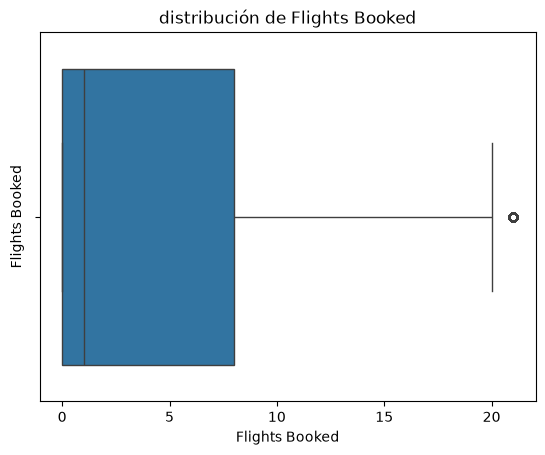

In [16]:
sns.boxplot(data=df_final, x='Flights Booked')
plt.title('distribución de Flights Booked')
plt.ylabel ('Flights Booked')
plt.show()

- En promedio, los clientes registran aproximadamente 4 reservas de vuelo.
- La mediana nos indica que al menos el 50% de los registros tiene 1 reserva o menos.
- La desviacion estandar presenta una alta variabilidad siendo 5.23
- El minimo de cero nos dice que hay registros sin reservas
- El maximo al ser 21 indica que hay clientes con un alta actividad por lo que 

los Flights Booked presentan una distribucion asimetrica positiva

In [15]:
resumen_analisis(df_final,'Flights with Companions')

,0
media,1.036569
mediana,0.000000
std,2.080472
min,0.000000
max,11.000000


In [32]:
(df_final["Flights with Companions"] == 0).mean() * 100

np.float64(73.06890231820884)

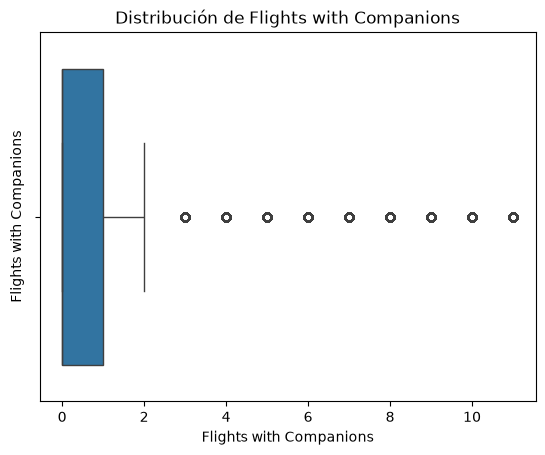

In [14]:
sns.boxplot(data=df_final, x='Flights with Companions')

plt.title('Distribución de Flights with Companions')
plt.ylabel('Flights with Companions')

plt.show()

- La mediana igual a cero indica que la mayoría de clientes no suele viajar acompañada. Sin embargo, algunos clientes registran valores significativamente superiores, alcanzando hasta 11 vuelos con acompañantes, lo que genera

In [35]:
resumen_analisis(df_final,'Total Flights')

,0
media,5.170619
mediana,1.000000
std,6.526858
min,0.000000
max,32.000000


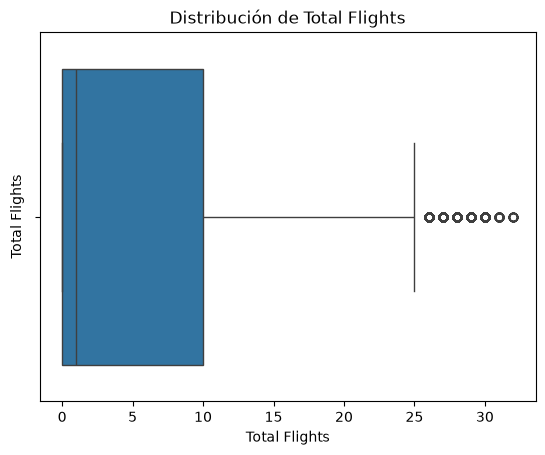

In [15]:
sns.boxplot(data=df_final, x='Total Flights')

plt.title('Distribución de Total Flights')
plt.ylabel('Total Flights')

plt.show()

- Gran parte de los clientes realiza pocos vuelos, existe un segmento reducido con una frecuencia de viaje significativamente superior, lo que incrementa la media general.

In [18]:
resumen_analisis(df_final,'Distance')

,0
media,1214.460979
mediana,525.000000
std,1434.098521
min,0.000000
max,6293.000000


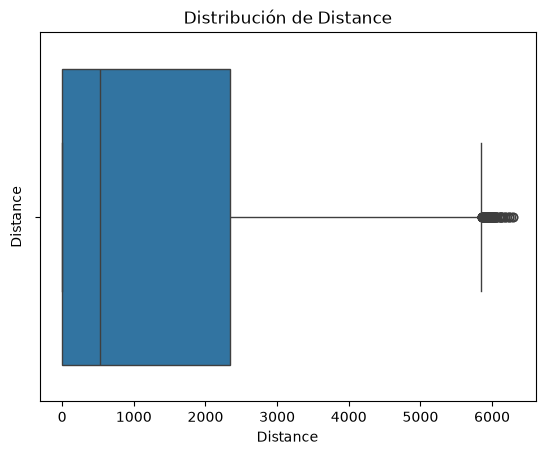

In [19]:
sns.boxplot(data=df_final, x='Distance')

plt.title('Distribución de Distance')
plt.ylabel('Distance')

plt.show()

- La distribucion de la distancia da una distribución asimétrica hacia valores altos. La mayoría de vuelos corresponde a trayectos relativamente cortos, mientras que un grupo reducido alcanza distancias considerablemente superiores, generando una alta dispersión en los datos.

In [53]:
resumen_analisis(df_final,'Salary')

,0
media,79869.502477
mediana,74173.000000
std,32094.584140
min,9081.000000
max,407228.000000


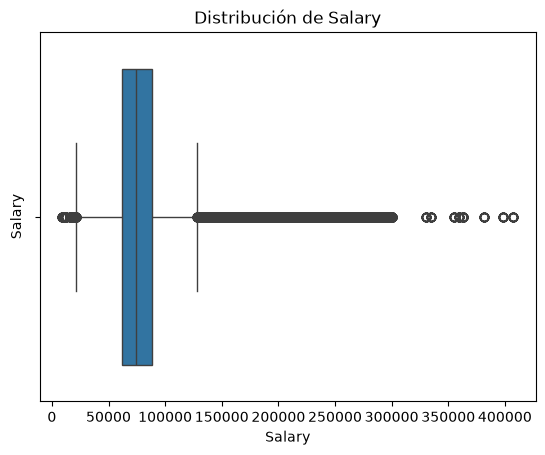

In [22]:
sns.boxplot(data=df_final, x='Salary')

plt.title('Distribución de Salary')
plt.ylabel('Salary')

plt.show()

Salary nos refleja que la mayoria de los clientes presentan un salario cercano al valor central. 
- El salario promedio de los clientes es de 79 mil al año
- La mitad de estos clientes gana 74 mil o menos
- Al tener una desviacion alta de 32, nos indica que los salarios estan bastante dispersos
- El salario minimo es de 9.081m frente al máximo de 407.228
Existen bastante variabilidad economica entre los clientes

In [51]:
resumen_analisis(df_final,'CLV')

,0
media,7990.864857
mediana,5776.340000
std,6863.317160
min,1898.010000
max,83325.380000


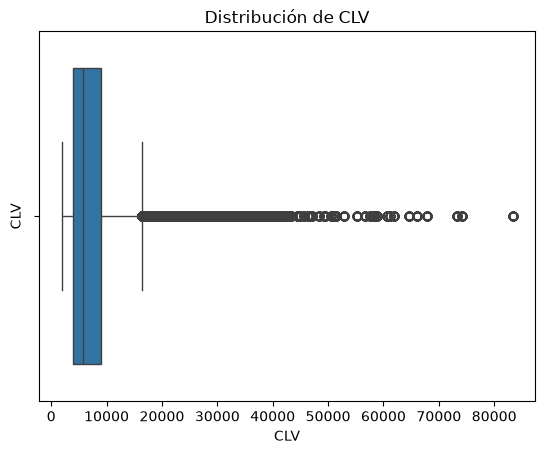

In [23]:
sns.boxplot(data=df_final, x='CLV')

plt.title('Distribución de CLV')
plt.ylabel('CLV')

plt.show()

El analisis del valor economico total que un cliente aporta a la empresa muestra una gran diferencia en el valor económico de los clientes. Aunque el valor medio ronda los 8 mil, algunos clientes generan ingresos muy superiores, lo que aumenta la media. Esto indica que una parte pequeña de clientes tiene un peso económico mucho mayor dentro del negocio.

# Buscamos los valores atipicos de las variables numericas

### 1º Buscamos la correlacion entre variables numericas

<Axes: >

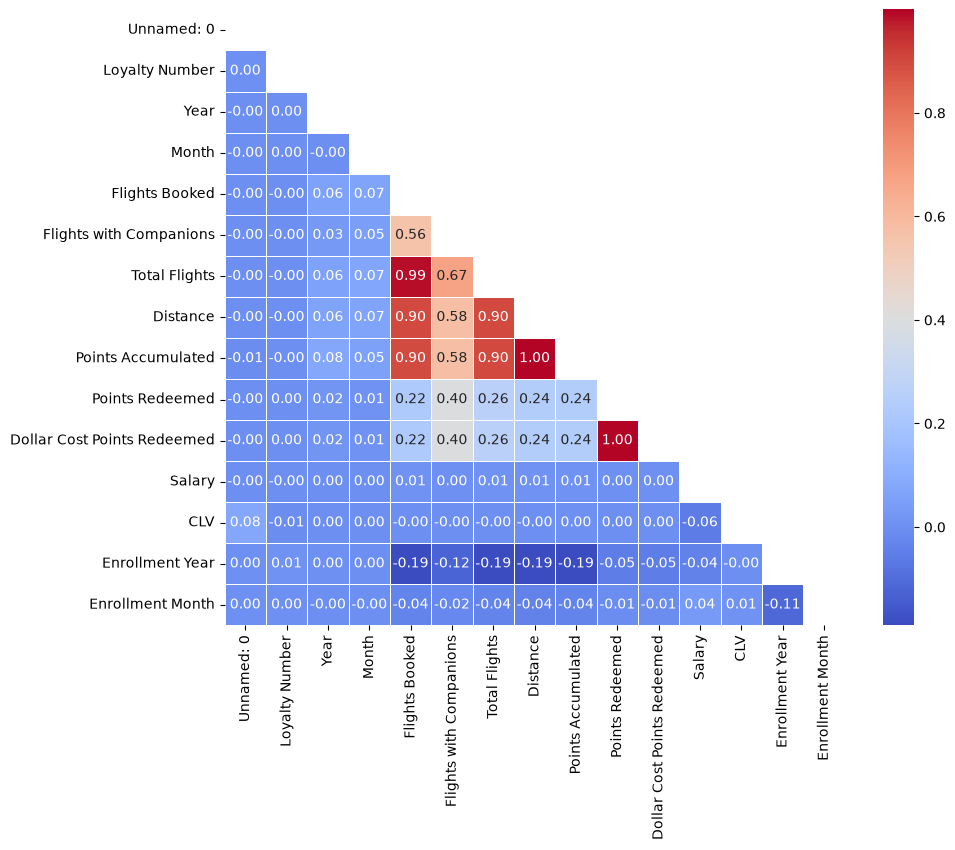

In [ ]:
# select_dtypes(include='number') = selecciona solo columnas numericas
# spearman = mide sin 2 variables cambian siguiendo una misma tendencia
matriz = df_final.select_dtypes(include='number').corr(method='spearman')
mask = np.triu(np.ones_like(matriz, dtype=bool))
plt.figure(figsize= (10, 8))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=mask)

- Podemos ver que total fligths y flights booked tienen una correlacion positiva (0.99), lo cual tiene sentido ya que cuando aumenta la cantidad de vuelos reservados, tambien aumenta el total de vuelos realizados. El resultado es el esperado.
- Ponts Accumulated y Distance tienen una correlacion positiva perfecta, indica que al aumentar la distancia de recorrido tambien aumenta los puntos acumulados.
- Dollar Cost Points Redeemed y points redeemed, aqui vemos otra correlacion positiva perfecta ya que exite una relacion matematica directa en cuanto mas puntos usados, mayor valor economico del vuelo

# Elegimos las columnas con valores categóricos son relevantes para el análisis.

In [11]:
columnas_categoricas = ["Gender", "Education", "Marital Status", "Loyalty Card", "Enrollment Type", "Province"]

In [9]:
def tabla_frecuencia (col):
    frecuencia_relativa = round(df_final[col].value_counts(normalize=True)*100,2)
 
    tabla_frecuencia= pd.DataFrame({
        col: frecuencia_relativa.index,
        'frecuencia_relativa' : frecuencia_relativa.values,
    })
   
    return tabla_frecuencia.set_index(col)

In [10]:
tabla_genero = tabla_frecuencia("Gender")
tabla_genero

,frecuencia_relativa
Gender,
Female,50.22
Male,49.78


In [13]:
tabla_educacion = tabla_frecuencia("Education")
tabla_educacion

,frecuencia_relativa
Education,
Bachelor,62.55
College,25.33
High School or Below,4.68
Doctor,4.39
Master,3.04


In [25]:
tabla_marital_status = tabla_frecuencia("Marital Status")
tabla_marital_status

,frecuencia_relativa
Marital Status,
Married,58.16
Single,26.79
Divorced,15.05


In [27]:
tabla_Loyalty_card = tabla_frecuencia("Loyalty Card")
tabla_Loyalty_card

,frecuencia_relativa
Loyalty Card,
Star,45.51
Nova,33.90
Aurora,20.59


In [29]:
tabla_Enrollment_type = tabla_frecuencia("Enrollment Type")
tabla_Enrollment_type

,frecuencia_relativa
Enrollment Type,
Standard,94.22
2018 Promotion,5.78


In [30]:
tabla_Province = tabla_frecuencia("Province")
tabla_Province

,frecuencia_relativa
Province,
Ontario,32.26
British Columbia,26.36
Quebec,19.71
Alberta,5.79
Manitoba,3.94
New Brunswick,3.80
Nova Scotia,3.10
Saskatchewan,2.44
Newfoundland,1.55


- Los valores categoricos nos muestran, que no hay gran diferencia en el numero de mujeres o hombres afiliados, tienen un nivel de estudios Bachelor, estan casados, poseen la tarjeta de laltar Star, el tipo de inscripcion es estandar y son de Canada, siendo la mayoria de las provincias de Ontario, Britich Columbia y Quebec.